In [1]:
# Setup and Imports
import sys
sys.path.append('em43_python')

from em43_notebook import EM43Trainer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set matplotlib style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Setup complete! Ready for learning curve analysis.")


✅ Setup complete! Ready for learning curve analysis.


In [4]:
# =================== EXPERIMENT PARAMETERS ===================

# Learning Task Definition
TASK_INPUTS = [i for i in range(1, 21)]
TASK_TARGETS = [i*2 for i in range(1, 21)]  # Double each input
TASK_NAME = "Double Numbers"

# Test Set for Evaluation
TEST_INPUTS = [i for i in range(22, 27)]
TEST_TARGETS = [i*2 for i in range(22, 27)]

# Evolution Parameters
POPULATION_SIZE = 2000
GENERATIONS = 100
N_SEEDS = 50  # Number of independent runs for statistical analysis

# Program Configuration
PROGRAM_LENGTH = 10  # Length of evolved programs
MAX_STEPS = 100       # Maximum CA steps during evaluation

# Methods to Compare
METHODS_TO_RUN = ['ga', 'random_search']  # Options: 'ga', 'random_search'

# 🆕 DIVERSITY PARAMETERS (NEW!)
# Enable diversity comparison for GA
ENABLE_DIVERSITY_COMPARISON = True  # Set to True to compare standard vs stochastic tournament GA
DIVERSITY_CONFIGS = {
    'standard_ga': {
        'enable_stochastic_tournament': False,
        'label': 'Standard GA'
    },
    'stochastic_ga': {
        'enable_stochastic_tournament': True,
        'initial_temperature': 2.0,
        'cooling_rate': 0.98,
        'min_temperature': 0.1,
        'label': 'Stochastic GA'
    }
}

# If diversity comparison is enabled, modify methods list
if ENABLE_DIVERSITY_COMPARISON:
    # Replace 'ga' with both variants
    if 'ga' in METHODS_TO_RUN:
        METHODS_TO_RUN.remove('ga')
        METHODS_TO_RUN.extend(['standard_ga', 'stochastic_ga'])

# Visualization Parameters
CONFIDENCE_ALPHA = 0.2  # Transparency for confidence intervals
FIGSIZE = (12, 8)       # Figure size for plots
SAMPLE_EVERY = 5        # Show every Nth generation in detailed plots

# Quick Test Mode (set True for faster testing)
QUICK_TEST = False
if QUICK_TEST:
    N_SEEDS = 5
    GENERATIONS = 20
    POPULATION_SIZE = 500
    print("⚠️  QUICK TEST MODE: Reduced parameters for faster execution")

print(f"📊 Experiment Setup:")
print(f"   Task: {TASK_NAME}")
print(f"   Population: {POPULATION_SIZE}")
print(f"   Generations: {GENERATIONS}")
print(f"   Seeds: {N_SEEDS}")
print(f"   Methods: {METHODS_TO_RUN}")
if ENABLE_DIVERSITY_COMPARISON:
    print(f"   🎯 Diversity Analysis: ENABLED")
    for config_name, config in DIVERSITY_CONFIGS.items():
        if config_name in METHODS_TO_RUN:
            print(f"      {config['label']}: {config}")
print(f"   Total samples per seed: {POPULATION_SIZE * GENERATIONS:,}")
print(f"   Estimated runtime: ~{(N_SEEDS * len(METHODS_TO_RUN) * GENERATIONS * 0.5):,.0f} seconds")


📊 Experiment Setup:
   Task: Double Numbers
   Population: 2000
   Generations: 100
   Seeds: 50
   Methods: ['ga', 'random_search']
   Total samples per seed: 200,000
   Estimated runtime: ~5,000 seconds


In [5]:
# Data storage for results
learning_curves_data = []
final_results = []

print("🔄 Starting learning curve experiments...")
print(f"   Total runs: {len(METHODS_TO_RUN)} methods × {N_SEEDS} seeds = {len(METHODS_TO_RUN) * N_SEEDS} experiments")

# Progress bar for overall experiment
total_experiments = len(METHODS_TO_RUN) * N_SEEDS
pbar_overall = tqdm(total=total_experiments, desc="Overall Progress")

for method in METHODS_TO_RUN:
    print(f"\n📈 Running {method.upper()} experiments...")
    
    for seed in range(N_SEEDS):
        # Determine trainer configuration
        if method in DIVERSITY_CONFIGS:
            # Use diversity configuration
            config = DIVERSITY_CONFIGS[method]
            base_method = 'ga'  # Both diversity variants use GA
            trainer_kwargs = {k: v for k, v in config.items() if k != 'label'}
        elif method == 'random_search':
            base_method = 'random_search'
            trainer_kwargs = {}
        else:
            # Standard method
            base_method = method
            trainer_kwargs = {}
        
        # Create trainer
        trainer = EM43Trainer(
            method=base_method,
            generations=GENERATIONS,
            pop_size=POPULATION_SIZE,
            prog_len=PROGRAM_LENGTH,
            max_steps=MAX_STEPS,
            seed=seed,
            verbose=False,  # Suppress output for cleaner notebook
            enable_logging=False,  # No CSV files
            **trainer_kwargs
        )
        
        # Run training
        genome, final_fitness = trainer.train(TASK_INPUTS, TASK_TARGETS)
        
        # Get learning curve (fitness over generations)
        fitness_curve = trainer.get_fitness_curve()
        
        # Evaluate on test set
        test_metrics = trainer.evaluate(TEST_INPUTS, TEST_TARGETS)
        
        # Store learning curve data
        for generation, fitness in enumerate(fitness_curve):
            samples = (generation + 1) * POPULATION_SIZE
            learning_curves_data.append({
                'method': method,
                'seed': seed,
                'generation': generation,
                'samples': samples,
                'fitness': fitness,
                'best_so_far': max(fitness_curve[:generation+1])  # Best fitness up to this point
            })
        
        # Store final results
        final_results.append({
            'method': method,
            'seed': seed,
            'final_fitness': final_fitness,
            'test_accuracy': test_metrics['accuracy'],
            'test_avg_error': test_metrics['avg_error'],
            'convergence_generation': len(fitness_curve)
        })
        
        pbar_overall.update(1)
        pbar_overall.set_postfix({
            'Method': method.upper(),
            'Seed': seed,
            'Final': f"{final_fitness:.3f}",
            'Test Acc': f"{test_metrics['accuracy']:.2f}"
        })

pbar_overall.close()

# Convert to DataFrames
df_curves = pd.DataFrame(learning_curves_data)
df_final = pd.DataFrame(final_results)

print(f"✅ Experiments complete!")
print(f"   Collected {len(df_curves)} data points")
print(f"   Final results for {len(df_final)} runs")
print(f"   Data shape: {df_curves.shape}")


🔄 Starting learning curve experiments...
   Total runs: 2 methods × 50 seeds = 100 experiments


Overall Progress:   0%|          | 0/100 [00:00<?, ?it/s]


📈 Running GA experiments...

📈 Running RANDOM_SEARCH experiments...
✅ Experiments complete!
   Collected 10000 data points
   Final results for 100 runs
   Data shape: (10000, 6)


In [6]:
# Summary statistics for final results
print("🔍 Final Results Summary:")
print("=" * 50)

for method in METHODS_TO_RUN:
    method_data = df_final[df_final['method'] == method]
    print(f"\n{method.upper()} Results ({len(method_data)} runs):")
    print(f"  Final Fitness: {method_data['final_fitness'].mean():.3f} ± {method_data['final_fitness'].std():.3f}")
    print(f"  Test Accuracy: {method_data['test_accuracy'].mean():.3f} ± {method_data['test_accuracy'].std():.3f}")
    print(f"  Test Avg Error: {method_data['test_avg_error'].mean():.3f} ± {method_data['test_avg_error'].std():.3f}")
    print(f"  Best Run Fitness: {method_data['final_fitness'].max():.3f}")
    print(f"  Worst Run Fitness: {method_data['final_fitness'].min():.3f}")

# Compute learning curve statistics (mean ± std over seeds)
print("\n📈 Computing learning curve statistics...")

# Group by method, generation, and samples to compute statistics across seeds
learning_stats = df_curves.groupby(['method', 'generation', 'samples']).agg({
    'fitness': ['mean', 'std', 'min', 'max', 'count'],
    'best_so_far': ['mean', 'std', 'min', 'max']
}).round(4)

# Flatten column names
learning_stats.columns = ['_'.join(col).strip() for col in learning_stats.columns]
learning_stats = learning_stats.reset_index()

print(f"✅ Learning curve statistics computed for {len(learning_stats)} data points")

# Calculate confidence intervals (95%)
learning_stats['fitness_ci_lower'] = learning_stats['fitness_mean'] - 1.96 * learning_stats['fitness_std'] / np.sqrt(learning_stats['fitness_count'])
learning_stats['fitness_ci_upper'] = learning_stats['fitness_mean'] + 1.96 * learning_stats['fitness_std'] / np.sqrt(learning_stats['fitness_count'])
learning_stats['best_ci_lower'] = learning_stats['best_so_far_mean'] - 1.96 * learning_stats['best_so_far_std'] / np.sqrt(learning_stats['fitness_count'])
learning_stats['best_ci_upper'] = learning_stats['best_so_far_mean'] + 1.96 * learning_stats['best_so_far_std'] / np.sqrt(learning_stats['fitness_count'])

# Data preview
print("\n📋 Learning Curve Data Preview:")
display(learning_stats.head(10))

# Check for any methods that didn't complete
incomplete_runs = df_final.groupby('method')['convergence_generation'].describe()
print("\n⚠️  Convergence Check:")
display(incomplete_runs)


🔍 Final Results Summary:

GA Results (50 runs):
  Final Fitness: -0.032 ± 0.120
  Test Accuracy: 0.968 ± 0.130
  Test Avg Error: 0.032 ± 0.130
  Best Run Fitness: -0.001
  Worst Run Fitness: -0.501

RANDOM_SEARCH Results (50 runs):
  Final Fitness: -2.135 ± 0.542
  Test Accuracy: 0.072 ± 0.175
  Test Avg Error: 7.976 ± 11.353
  Best Run Fitness: -0.504
  Worst Run Fitness: -3.202

📈 Computing learning curve statistics...
✅ Learning curve statistics computed for 200 data points

📋 Learning Curve Data Preview:


,method,generation,samples,fitness_mean,fitness_std,fitness_min,fitness_max,fitness_count,best_so_far_mean,best_so_far_std,best_so_far_min,best_so_far_max,fitness_ci_lower,fitness_ci_upper,best_ci_lower,best_ci_upper
0,ga,0,2000,-6.3139,1.6281,-9.502,-1.956,50,-6.3139,1.6281,-9.502,-1.956,-6.765186,-5.862614,-6.765186,-5.862614
1,ga,1,4000,-5.6428,1.5297,-9.002,-1.956,50,-5.6428,1.5297,-9.002,-1.956,-6.066811,-5.218789,-6.066811,-5.218789
2,ga,2,6000,-2.0992,2.3703,-8.404,-0.001,50,-2.0992,2.3703,-8.404,-0.001,-2.756214,-1.442186,-2.756214,-1.442186
3,ga,3,8000,-2.0880,2.1443,-6.504,-0.001,50,-1.8690,2.0358,-6.504,-0.001,-2.682370,-1.493630,-2.433295,-1.304705
4,ga,4,10000,-1.7572,1.8836,-6.402,-0.001,50,-1.6110,1.8839,-6.402,-0.001,-2.279307,-1.235093,-2.133190,-1.088810
5,ga,5,12000,-1.5531,1.7082,-5.453,-0.001,50,-1.4649,1.6860,-5.453,-0.001,-2.026589,-1.079611,-1.932235,-0.997565
6,ga,6,14000,-1.3040,1.5820,-5.453,-0.001,50,-1.2240,1.5434,-5.453,-0.001,-1.742508,-0.865492,-1.651809,-0.796191
7,ga,7,16000,-1.2069,1.5324,-5.453,-0.001,50,-1.0800,1.4767,-5.453,-0.001,-1.631660,-0.782140,-1.489320,-0.670680
8,ga,8,18000,-1.1168,1.4834,-5.404,-0.001,50,-0.9571,1.3940,-5.404,-0.001,-1.527978,-0.705622,-1.343497,-0.570703
9,ga,9,20000,-1.0107,1.4548,-5.104,-0.001,50,-0.9039,1.3885,-5.104,-0.001,-1.413950,-0.607450,-1.288773,-0.519027



⚠️  Convergence Check:


,count,mean,std,min,25%,50%,75%,max
method,,,,,,,,
ga,50.0,100.0,0.0,100.0,100.0,100.0,100.0,100.0
random_search,50.0,100.0,0.0,100.0,100.0,100.0,100.0,100.0


📊 Creating main learning curve plots...


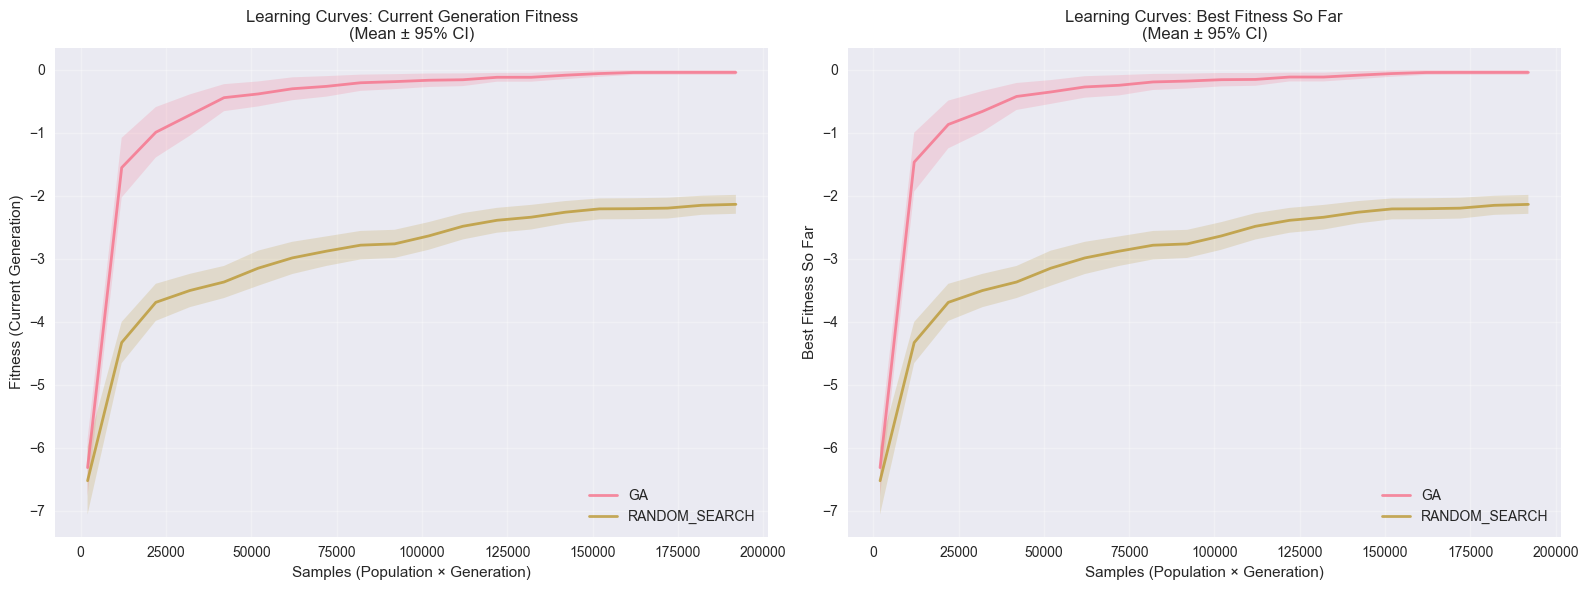


📉 Creating convergence analysis...


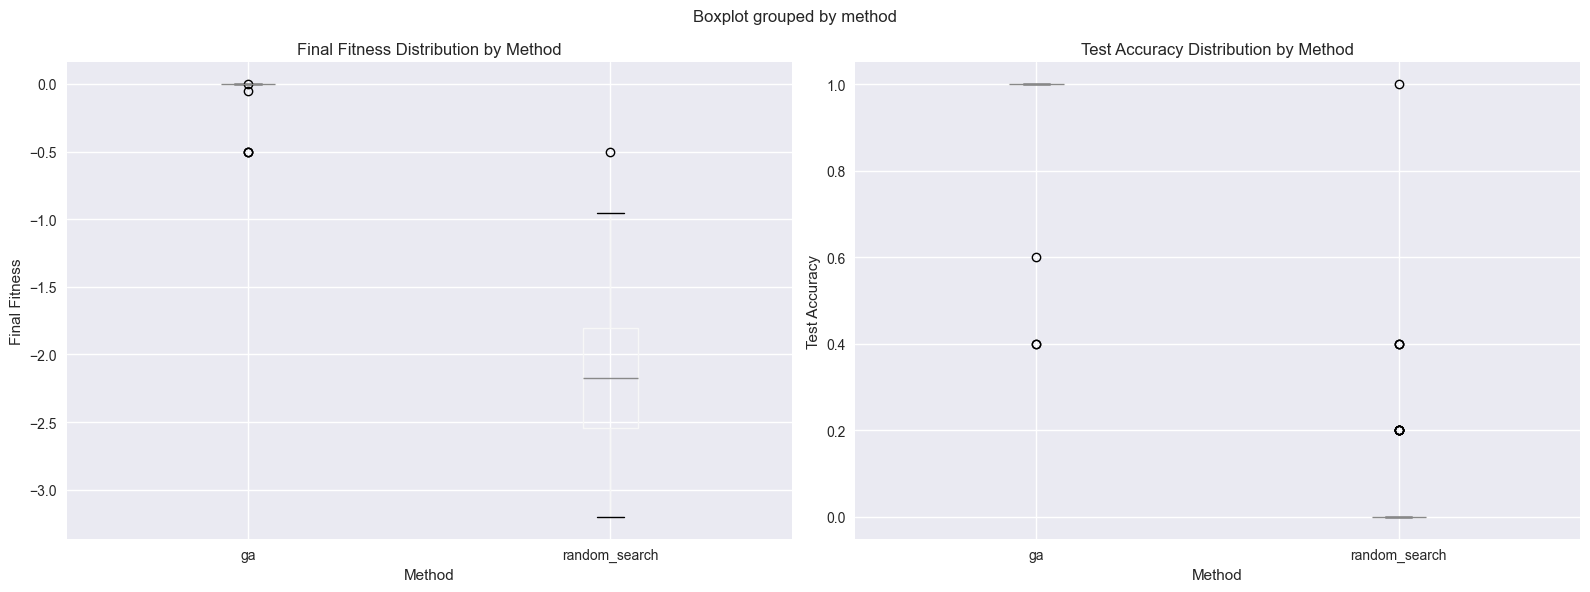


⚡ Creating sample efficiency analysis...


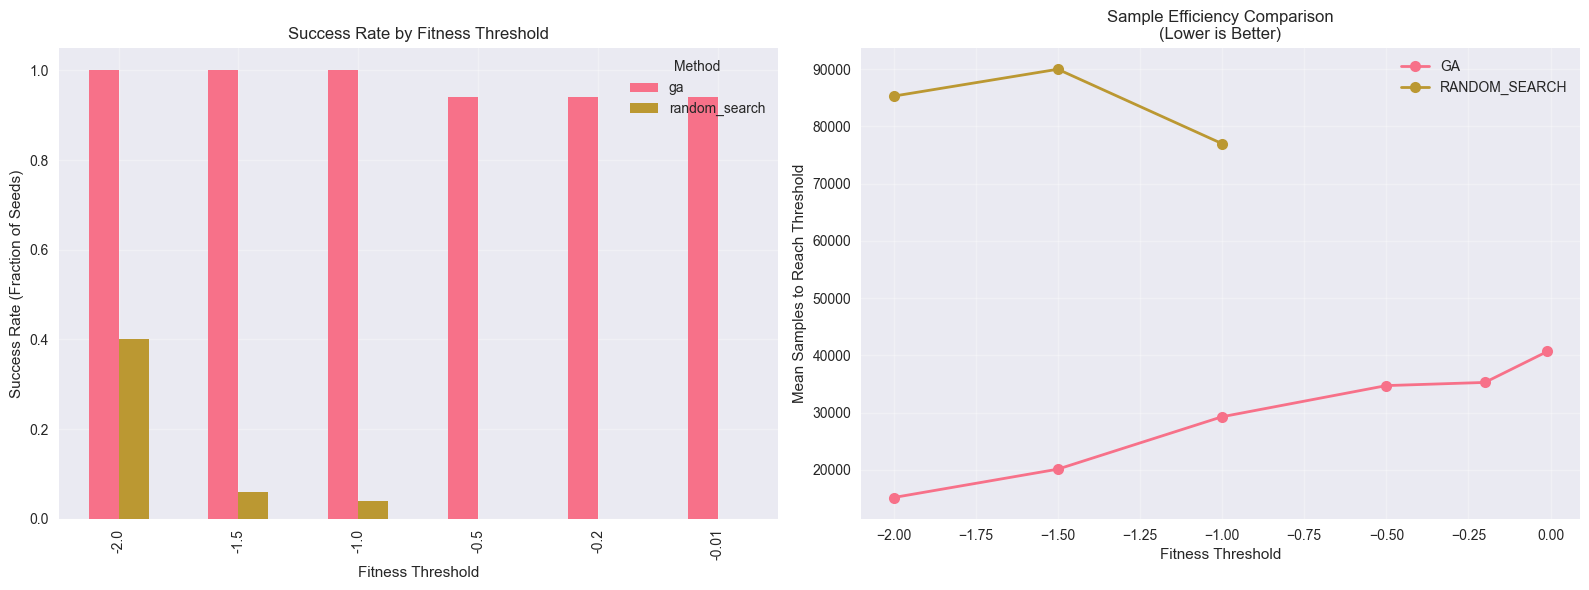

✅ All visualizations complete!


In [12]:
# 1. Main Learning Curves: Fitness vs Samples
print("📊 Creating main learning curve plots...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Current generation fitness (more noisy)
for i, method in enumerate(METHODS_TO_RUN):
    method_data = learning_stats[learning_stats['method'] == method]
    
    # Sample data for cleaner visualization
    sampled_data = method_data[method_data['generation'] % SAMPLE_EVERY == 0]
    
    # Get display label
    if method in DIVERSITY_CONFIGS:
        display_label = DIVERSITY_CONFIGS[method]['label']
    else:
        display_label = method.upper()
    
    ax1.plot(sampled_data['samples'], sampled_data['fitness_mean'], 
             label=display_label, linewidth=2, alpha=0.8)
    ax1.fill_between(sampled_data['samples'], 
                     sampled_data['fitness_ci_lower'], 
                     sampled_data['fitness_ci_upper'],
                     alpha=CONFIDENCE_ALPHA)

ax1.set_xlabel('Samples (Population × Generation)')
ax1.set_ylabel('Fitness (Current Generation)')
ax1.set_title('Learning Curves: Current Generation Fitness\n(Mean ± 95% CI)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Best-so-far fitness (monotonic improvement)
for i, method in enumerate(METHODS_TO_RUN):
    method_data = learning_stats[learning_stats['method'] == method]
    
    # Sample data for cleaner visualization
    sampled_data = method_data[method_data['generation'] % SAMPLE_EVERY == 0]
    
    # Get display label
    if method in DIVERSITY_CONFIGS:
        display_label = DIVERSITY_CONFIGS[method]['label']
    else:
        display_label = method.upper()
    
    ax2.plot(sampled_data['samples'], sampled_data['best_so_far_mean'], 
             label=display_label, linewidth=2, alpha=0.8)
    ax2.fill_between(sampled_data['samples'], 
                     sampled_data['best_ci_lower'], 
                     sampled_data['best_ci_upper'],
                     alpha=CONFIDENCE_ALPHA)

ax2.set_xlabel('Samples (Population × Generation)')
ax2.set_ylabel('Best Fitness So Far')
ax2.set_title('Learning Curves: Best Fitness So Far\n(Mean ± 95% CI)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Convergence Analysis
print("\n📉 Creating convergence analysis...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot final fitness distributions
df_final.boxplot(column='final_fitness', by='method', ax=ax1)
ax1.set_title('Final Fitness Distribution by Method')
ax1.set_xlabel('Method')
ax1.set_ylabel('Final Fitness')

# Plot test accuracy distributions  
df_final.boxplot(column='test_accuracy', by='method', ax=ax2)
ax2.set_title('Test Accuracy Distribution by Method')
ax2.set_xlabel('Method')
ax2.set_ylabel('Test Accuracy')

plt.tight_layout()
plt.show()

# 3. Sample Efficiency Comparison
print("\n⚡ Creating sample efficiency analysis...")

# Find when each method reaches certain fitness thresholds
thresholds = [-2.0, -1.5, -1.0, -0.5, -0.2, -0.01]
efficiency_data = []

for method in METHODS_TO_RUN:
    method_curves = df_curves[df_curves['method'] == method]
    
    for threshold in thresholds:
        # Find first time each seed reaches threshold
        first_reach = []
        for seed in range(N_SEEDS):
            seed_data = method_curves[method_curves['seed'] == seed]
            reaching_rows = seed_data[seed_data['best_so_far'] >= threshold]
            if len(reaching_rows) > 0:
                first_reach.append(reaching_rows.iloc[0]['samples'])
        
        efficiency_data.append({
            'method': method,
            'threshold': threshold,
            'success_rate': len(first_reach) / N_SEEDS,
            'mean_samples': np.mean(first_reach) if first_reach else np.inf,
            'std_samples': np.std(first_reach) if first_reach else 0
        })

df_efficiency = pd.DataFrame(efficiency_data)

# Plot sample efficiency
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Success rates
pivot_success = df_efficiency.pivot(index='threshold', columns='method', values='success_rate')
pivot_success.plot(kind='bar', ax=ax1)
ax1.set_title('Success Rate by Fitness Threshold')
ax1.set_xlabel('Fitness Threshold')
ax1.set_ylabel('Success Rate (Fraction of Seeds)')
ax1.legend(title='Method')
ax1.grid(True, alpha=0.3)

# Sample efficiency (only for successful runs)
for method in METHODS_TO_RUN:
    method_eff = df_efficiency[df_efficiency['method'] == method]
    # Only plot where success rate > 0
    valid_data = method_eff[method_eff['success_rate'] > 0]
    if len(valid_data) > 0:
        ax2.plot(valid_data['threshold'], valid_data['mean_samples'], 
                'o-', label=f'{method.upper()}', linewidth=2, markersize=8)

ax2.set_xlabel('Fitness Threshold')
ax2.set_ylabel('Mean Samples to Reach Threshold')
ax2.set_title('Sample Efficiency Comparison\n(Lower is Better)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ All visualizations complete!")


In [8]:
# Statistical comparison between methods
from scipy import stats

if len(METHODS_TO_RUN) == 2:
    print("🧮 Statistical Comparison Between Methods:")
    print("=" * 50)
    
    method1, method2 = METHODS_TO_RUN
    data1 = df_final[df_final['method'] == method1]
    data2 = df_final[df_final['method'] == method2]
    
    # Compare final fitness
    fitness1 = data1['final_fitness'].values
    fitness2 = data2['final_fitness'].values
    
    # Normality tests
    _, p_norm1 = stats.shapiro(fitness1)
    _, p_norm2 = stats.shapiro(fitness2)
    normal = (p_norm1 > 0.05) and (p_norm2 > 0.05)
    
    print(f"\n📈 Final Fitness Comparison:")
    print(f"   {method1.upper()}: {fitness1.mean():.3f} ± {fitness1.std():.3f}")
    print(f"   {method2.upper()}: {fitness2.mean():.3f} ± {fitness2.std():.3f}")
    
    # Choose appropriate test
    if normal:
        stat, p_value = stats.ttest_ind(fitness1, fitness2)
        test_name = "t-test"
    else:
        stat, p_value = stats.mannwhitneyu(fitness1, fitness2, alternative='two-sided')
        test_name = "Mann-Whitney U"
    
    # Effect size (Cohen's d)
    pooled_std = np.sqrt(((len(fitness1)-1)*fitness1.var() + (len(fitness2)-1)*fitness2.var()) / (len(fitness1)+len(fitness2)-2))
    cohens_d = (fitness1.mean() - fitness2.mean()) / pooled_std
    
    print(f"\n🔬 Statistical Test Results ({test_name}):")
    print(f"   Test statistic: {stat:.3f}")
    print(f"   p-value: {p_value:.6f}")
    print(f"   Significant (α=0.05): {'Yes' if p_value < 0.05 else 'No'}")
    print(f"   Cohen's d: {cohens_d:.3f}")
    
    # Effect size interpretation
    if abs(cohens_d) < 0.2:
        effect_size = "negligible"
    elif abs(cohens_d) < 0.5:
        effect_size = "small"
    elif abs(cohens_d) < 0.8:
        effect_size = "medium"
    else:
        effect_size = "large"
    
    print(f"   Effect size: {effect_size}")
    
    # Compare test accuracy
    acc1 = data1['test_accuracy'].values
    acc2 = data2['test_accuracy'].values
    
    print(f"\n🎯 Test Accuracy Comparison:")
    print(f"   {method1.upper()}: {acc1.mean():.3f} ± {acc1.std():.3f}")
    print(f"   {method2.upper()}: {acc2.mean():.3f} ± {acc2.std():.3f}")
    
    if normal:
        stat_acc, p_acc = stats.ttest_ind(acc1, acc2)
    else:
        stat_acc, p_acc = stats.mannwhitneyu(acc1, acc2, alternative='two-sided')
    
    print(f"   {test_name} p-value: {p_acc:.6f}")
    print(f"   Significant (α=0.05): {'Yes' if p_acc < 0.05 else 'No'}")

else:
    print("📊 Method-wise Summary Statistics:")
    for method in METHODS_TO_RUN:
        method_data = df_final[df_final['method'] == method]
        print(f"\n{method.upper()}:")
        print(f"  N = {len(method_data)}")
        print(f"  Final Fitness: {method_data['final_fitness'].mean():.3f} ± {method_data['final_fitness'].std():.3f}")
        print(f"  Test Accuracy: {method_data['test_accuracy'].mean():.3f} ± {method_data['test_accuracy'].std():.3f}")

# Learning curve convergence analysis
print(f"\n⏱️  Convergence Analysis:")
print("=" * 30)

final_generation_stats = df_curves.groupby(['method', 'seed'])['generation'].max().reset_index()
convergence_summary = final_generation_stats.groupby('method')['generation'].agg(['mean', 'std', 'min', 'max'])

for method in METHODS_TO_RUN:
    stats = convergence_summary.loc[method]
    print(f"{method.upper()}: {stats['mean']:.1f} ± {stats['std']:.1f} generations (range: {stats['min']}-{stats['max']})")

# Sample efficiency summary
print(f"\n⚡ Sample Efficiency Summary:")
print("=" * 35)

for threshold in [-1.5, -1.0, -0.5]:
    print(f"\nFitness ≥ {threshold}:")
    for method in METHODS_TO_RUN:
        method_eff = df_efficiency[(df_efficiency['method'] == method) & (df_efficiency['threshold'] == threshold)]
        if len(method_eff) > 0:
            success_rate = method_eff.iloc[0]['success_rate']
            mean_samples = method_eff.iloc[0]['mean_samples']
            print(f"  {method.upper()}: {success_rate:.1%} success, {mean_samples:,.0f} samples" if success_rate > 0 else f"  {method.upper()}: {success_rate:.1%} success")


🧮 Statistical Comparison Between Methods:

📈 Final Fitness Comparison:
   GA: -0.032 ± 0.119
   RANDOM_SEARCH: -2.135 ± 0.537

🔬 Statistical Test Results (Mann-Whitney U):
   Test statistic: 2500.000
   p-value: 0.000000
   Significant (α=0.05): Yes
   Cohen's d: 5.410
   Effect size: large

🎯 Test Accuracy Comparison:
   GA: 0.968 ± 0.129
   RANDOM_SEARCH: 0.072 ± 0.173
   Mann-Whitney U p-value: 0.000000
   Significant (α=0.05): Yes

⏱️  Convergence Analysis:
GA: 99.0 ± 0.0 generations (range: 99.0-99.0)
RANDOM_SEARCH: 99.0 ± 0.0 generations (range: 99.0-99.0)

⚡ Sample Efficiency Summary:

Fitness ≥ -1.5:
  GA: 100.0% success, 20,120 samples
  RANDOM_SEARCH: 6.0% success, 90,000 samples

Fitness ≥ -1.0:
  GA: 100.0% success, 29,280 samples
  RANDOM_SEARCH: 4.0% success, 77,000 samples

Fitness ≥ -0.5:
  GA: 94.0% success, 34,723 samples
  RANDOM_SEARCH: 0.0% success


In [9]:
# Save results to CSV files for further analysis
import os
from datetime import datetime

SAVE_RESULTS = True  # Set to False to skip saving

if SAVE_RESULTS:
    # Create results directory if it doesn't exist
    results_dir = "learning_curve_results"
    os.makedirs(results_dir, exist_ok=True)
    
    # Generate timestamp for unique filenames
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Save raw learning curves data
    curves_filename = f"{results_dir}/learning_curves_{timestamp}.csv"
    df_curves.to_csv(curves_filename, index=False)
    print(f"💾 Learning curves data saved to: {curves_filename}")
    
    # Save final results summary
    final_filename = f"{results_dir}/final_results_{timestamp}.csv"
    df_final.to_csv(final_filename, index=False)
    print(f"💾 Final results saved to: {final_filename}")
    
    # Save aggregated statistics
    stats_filename = f"{results_dir}/learning_stats_{timestamp}.csv"
    learning_stats.to_csv(stats_filename, index=False)
    print(f"💾 Learning statistics saved to: {stats_filename}")
    
    # Save efficiency analysis
    efficiency_filename = f"{results_dir}/efficiency_analysis_{timestamp}.csv"
    df_efficiency.to_csv(efficiency_filename, index=False)
    print(f"💾 Efficiency analysis saved to: {efficiency_filename}")
    
    # Save experimental parameters
    params_filename = f"{results_dir}/experiment_params_{timestamp}.txt"
    with open(params_filename, 'w') as f:
        f.write("EM43 Learning Curve Analysis - Experimental Parameters\n")
        f.write(f"Timestamp: {datetime.now()}\n")
        f.write("=" * 60 + "\n\n")
        f.write(f"Task: {TASK_NAME}\n")
        f.write(f"Task Inputs: {TASK_INPUTS}\n")
        f.write(f"Task Targets: {TASK_TARGETS}\n")
        f.write(f"Test Inputs: {TEST_INPUTS}\n")
        f.write(f"Test Targets: {TEST_TARGETS}\n\n")
        f.write(f"Population Size: {POPULATION_SIZE}\n")
        f.write(f"Generations: {GENERATIONS}\n")
        f.write(f"Number of Seeds: {N_SEEDS}\n")
        f.write(f"Program Length: {PROGRAM_LENGTH}\n")
        f.write(f"Max Steps: {MAX_STEPS}\n")
        f.write(f"Methods: {METHODS_TO_RUN}\n\n")
        f.write(f"Total Samples per Run: {POPULATION_SIZE * GENERATIONS:,}\n")
        f.write(f"Total Experiments: {len(METHODS_TO_RUN) * N_SEEDS}\n")
        f.write(f"Quick Test Mode: {QUICK_TEST}\n")
    
    print(f"💾 Experimental parameters saved to: {params_filename}")
    print(f"\n📁 All results saved in directory: {results_dir}/")
    
else:
    print("💾 Saving disabled. Set SAVE_RESULTS = True to save results.")


💾 Learning curves data saved to: learning_curve_results/learning_curves_20250701_160855.csv
💾 Final results saved to: learning_curve_results/final_results_20250701_160855.csv
💾 Learning statistics saved to: learning_curve_results/learning_stats_20250701_160855.csv
💾 Efficiency analysis saved to: learning_curve_results/efficiency_analysis_20250701_160855.csv
💾 Experimental parameters saved to: learning_curve_results/experiment_params_20250701_160855.txt

📁 All results saved in directory: learning_curve_results/
